# Hands-On with Real Data: Autoencoders and Generative Adversarial Network (Vanila Encoder Version)




In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.utils import make_grid
from torch.utils.data import DataLoader, ConcatDataset, random_split
from torchvision import datasets, transforms, utils
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') #shift to GPU if available
print("Using device:", device)

Using device: cuda


## Load and Preprocess data

In [ ]:
transform = transforms.ToTensor()

# Load and split MNIST
full_mnist = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_len = int(0.7 * len(full_mnist))
val_len   = len(full_mnist) - train_len
train_mnist, _ = random_split(full_mnist, [train_len, val_len], generator=torch.Generator().manual_seed(42))

# Load and split Fashion-MNIST
full_fmnist = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
train_len = int(0.7 * len(full_fmnist))
val_len   = len(full_fmnist) - train_len
train_fmnist, _ = random_split(full_fmnist, [train_len, val_len], generator=torch.Generator().manual_seed(42))

# Combined training set
train_combined = ConcatDataset([train_mnist, train_fmnist])

# DataLoaders
batch_size = 256
loader_mnist    = DataLoader(train_mnist,    batch_size=batch_size, shuffle=True, drop_last=True)
loader_fmnist   = DataLoader(train_fmnist,   batch_size=batch_size, shuffle=True, drop_last=True)
loader_combined = DataLoader(train_combined, batch_size=batch_size, shuffle=True, drop_last=True)

# Get one batch from each loader
mnist_batch, _ = next(iter(loader_mnist))
fmnist_batch, _ = next(iter(loader_fmnist))
combined_batch, _ = next(iter(loader_combined))

# Print the shapes of the batches
print("MNIST batch shape:", mnist_batch.shape)
print("FashionMNIST batch shape:", fmnist_batch.shape)
print("Combined batch shape:", combined_batch.shape)

100%|██████████| 9.91M/9.91M [00:00<00:00, 10.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 806kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.99MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.52MB/s]
100%|██████████| 26.4M/26.4M [00:04<00:00, 6.46MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 247kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.69MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 2.56MB/s]

MNIST batch shape: torch.Size([256, 1, 28, 28])
FashionMNIST batch shape: torch.Size([256, 1, 28, 28])
Combined batch shape: torch.Size([256, 1, 28, 28])


## Step 4: Train Generative Adversarial Networks (GANs)
- Implement a GAN architecture for 28×28 grayscale images.
- Train the GAN on MNIST, Fashion-MNIST, and the combined dataset.
- At regular intervals, save generated images to monitor training progress.
- Generate a grid of synthetic images after training for each dataset.
- Save the trained models.

## Dataset Description 
We will work with two commonly used image datasets:
- **Fashion-MNIST:** Fashion item images (10 classes), 28×28 pixels, 60,000 training and 10,000 test. 
- **MNIST:** Handwritten digits (0–9), 28×28 pixels, 60,000 training and 10,000 test images 
- **Combined dataset:** You will also create a combined dataset by concatenating the MNIST and Fashion-MNIST 
sets. 

### Creating a generator and discriminator network

In [ ]:
latent_dim = 200 #noise vector dimension

class Generator(nn.Module): # Generator for MNIST and Fashion-MNIST
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 7*7*128, bias=False), # 7x7x128
            nn.BatchNorm1d(7*7*128), 
            nn.LeakyReLU(0.2, inplace=True),
            nn.Unflatten(1, (128, 7, 7)), # reshape to 128x7x7
            nn.ConvTranspose2d(128, 64, 5, 2, 2, output_padding=1, bias=False), # 14x14
            nn.BatchNorm2d(64), 
            nn.LeakyReLU(0.2, inplace=True), 
            nn.ConvTranspose2d(64, 1, 5, 2, 2, output_padding=1), # 28x28
            nn.Sigmoid()  # outputs in [0,1]
        )
    def forward(self, z):
        return self.model(z)

class Discriminator(nn.Module): # Discriminator for MNIST and Fashion-MNIST
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential( 
            nn.Conv2d(1, 64, 5, 2, 2), # 14x14
            nn.LeakyReLU(0.2, inplace=True), # 64 channels
            nn.Dropout(0.3), # dropout for regularization
            nn.Conv2d(64, 128, 5, 2, 2), 
            nn.LeakyReLU(0.2, inplace=True), 
            nn.Dropout(0.3),
            nn.Flatten(),
            nn.Linear(128*7*7, 1),
            nn.Sigmoid() # output probability
        )
    def forward(self, x):
        return self.model(x)

# Instantiate
generator     = Generator().to(device)
discriminator = Discriminator().to(device)

# Loss and optimizers
criterion = nn.BCELoss()
optim_d   = optim.Adam(discriminator.parameters(), lr=2e-4, betas=(0.5,0.999)) # Discriminator optimizer
optim_g   = optim.Adam(generator.parameters(),     lr=1e-4, betas=(0.5,0.999)) # Generator optimizer


## Train Generative Adversarial Network
- Tune Hyperparamaters
- Fixed noise initialization for sample generation
- Batch processing for discriminator updates
- Discriminator Updates: 
    - Process Half-batch of real images, compute loss against ones
    - Generate Half-batch of fake images using random noise, compute loss against zeroes
    - Combine and backpropogate discriminator loss, update optimizer
    - Compute accuracy for real and fake predictions.
- Generator Updates:
    - Use batch of random noise to generate images
    - Calculate generator loss by using generated images from the descriminator with label of ones to try and fool the discriminator.
    - Backpropogates and updates optimizer.

In [ ]:
epochs        = 200
batch_size    = 64
save_interval = 10
d_steps       = 1
sample_size   = 25
latent_dim    = 200
lr_d          = 0.0001  # slower D
lr_g          = 0.0010  # faster G

def train_gan(dataloader, name):
    fixed_noise = torch.randn(sample_size, latent_dim, device=device)
    output_dir  = f'outputs/GAN_{name}'
    os.makedirs(output_dir, exist_ok=True)

    for epoch in range(1, epochs + 1):
        for real_imgs, _ in dataloader:
            real_imgs = real_imgs.to(device)
            half = batch_size // 2

            # Discriminator updates
            for _ in range(d_steps): # multiple updates for discriminator
                optim_d.zero_grad()
                real_half    = real_imgs[:half]
                labels_real  = torch.ones(half, 1, device=device)
                out_real     = discriminator(real_half)
                loss_real    = criterion(out_real, labels_real)

                noise        = torch.randn(half, latent_dim, device=device) #generate noise
                fake         = generator(noise).detach() 
                labels_fake  = torch.zeros(half, 1, device=device) #fake labels
                out_fake     = discriminator(fake)
                loss_fake    = criterion(out_fake, labels_fake)

                loss_d = loss_real + loss_fake 
                loss_d.backward() #backpropagate
                optim_d.step()

                preds = torch.cat([out_real, out_fake]) 
                labels = torch.cat([labels_real, labels_fake]) 
                d_acc = (preds.round() == labels).float().mean() 

            # Generator update
            optim_g.zero_grad()
            noise_full      = torch.randn(batch_size, latent_dim, device=device) #generate full noise
            misleading_lbls = torch.ones(batch_size, 1, device=device)
            out_gen         = discriminator(generator(noise_full))
            loss_g          = criterion(out_gen, misleading_lbls) #generator loss
            loss_g.backward() #backpropagate
            optim_g.step() #update generator

        if epoch % save_interval == 0 or epoch == 1:
            print(f"[{name}] Epoch {epoch}/{epochs}  "
                  f"D_loss: {loss_d.item():.4f}  D_acc: {d_acc.item():.4f}  G_loss: {loss_g.item():.4f}")
            with torch.no_grad():
                samples = generator(fixed_noise).cpu()
            utils.save_image(
                samples.view(sample_size, 1, 28, 28),
                os.path.join(output_dir, f"{name}_epoch{epoch}.png"), #save generated images
                nrow=int(sample_size**0.5), normalize=True
            )
            grid = utils.make_grid(samples.view(sample_size, 1, 28, 28),
                                   nrow=int(sample_size**0.5), normalize=True)
            plt.figure(figsize=(5,5))
            plt.imshow(grid.permute(1, 2, 0))
            plt.axis('off')
            plt.title(f"{name} Epoch {epoch}")
            plt.show()

    with torch.no_grad():
        final = generator(fixed_noise).cpu()
    utils.save_image(
        final.view(sample_size, 1, 28, 28),
        os.path.join(output_dir, f"{name}_final.png"), 
        nrow=int(sample_size**0.5), normalize=True 
    )
    torch.save(generator.state_dict(),     os.path.join(output_dir, f"generator_{name}.pth")) #save trained models
    torch.save(discriminator.state_dict(), os.path.join(output_dir, f"discriminator_{name}.pth"))


### Call Training function

[MNIST] Epoch 1/200  D_loss: 0.0191  D_acc: 1.0000  G_loss: 5.0070


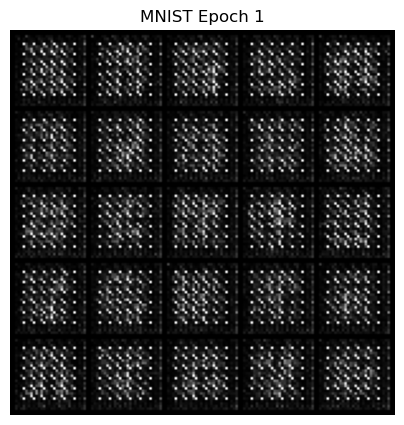

[MNIST] Epoch 10/200  D_loss: 1.1240  D_acc: 0.6719  G_loss: 1.1605


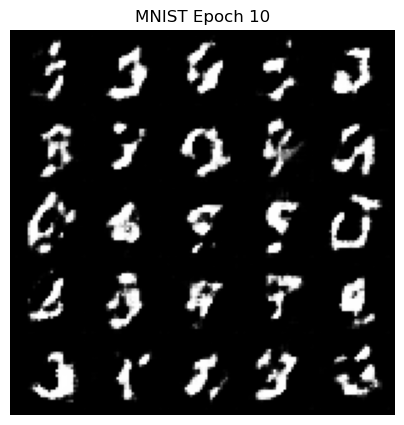

[MNIST] Epoch 20/200  D_loss: 0.9134  D_acc: 0.7969  G_loss: 1.4822


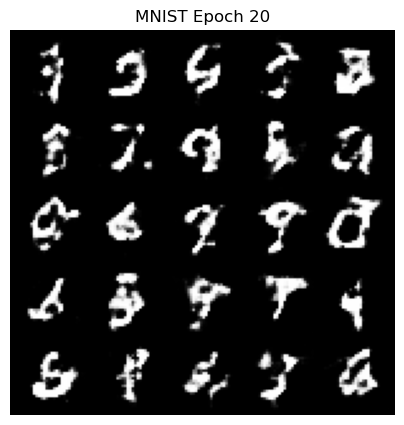

[MNIST] Epoch 30/200  D_loss: 0.9424  D_acc: 0.7812  G_loss: 1.2448


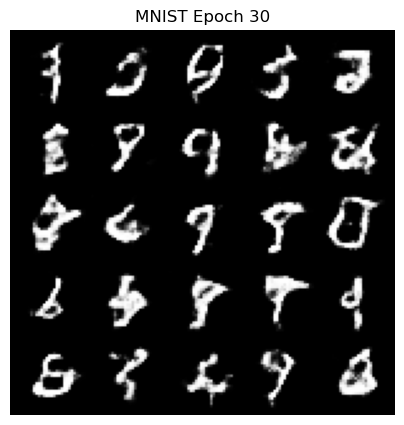

[MNIST] Epoch 40/200  D_loss: 0.8104  D_acc: 0.8438  G_loss: 0.8459


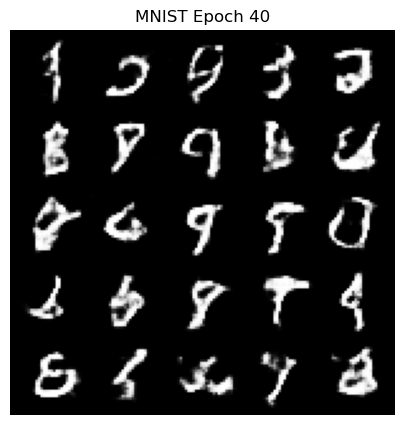

[MNIST] Epoch 50/200  D_loss: 1.0721  D_acc: 0.7344  G_loss: 0.9280


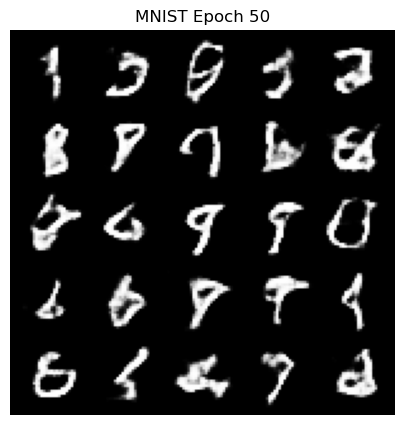

[MNIST] Epoch 60/200  D_loss: 1.0794  D_acc: 0.7344  G_loss: 0.9493


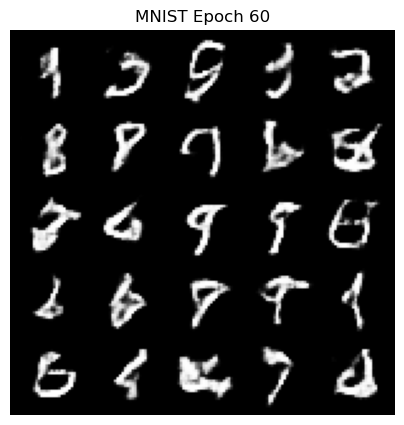

[MNIST] Epoch 70/200  D_loss: 1.0553  D_acc: 0.7188  G_loss: 1.0536


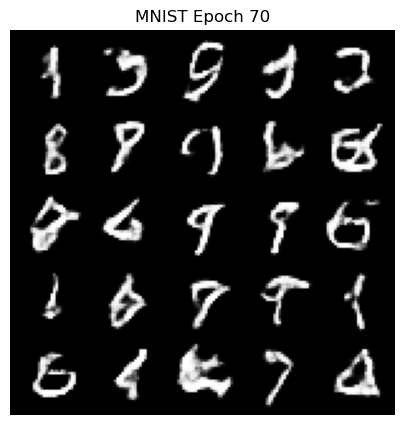

[MNIST] Epoch 80/200  D_loss: 1.0993  D_acc: 0.7344  G_loss: 1.3699


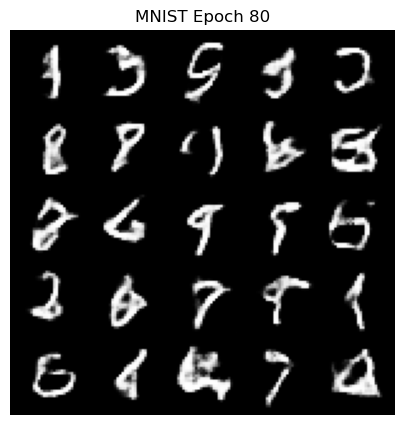

[MNIST] Epoch 90/200  D_loss: 0.9316  D_acc: 0.7812  G_loss: 1.2157


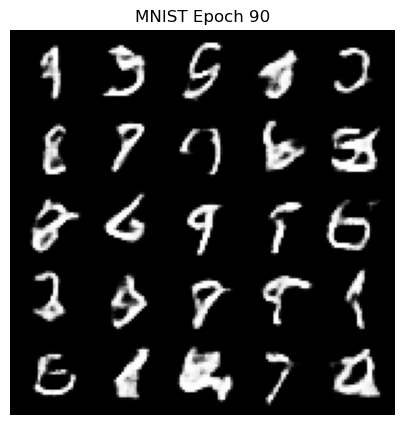

[MNIST] Epoch 100/200  D_loss: 0.9785  D_acc: 0.7344  G_loss: 1.2449


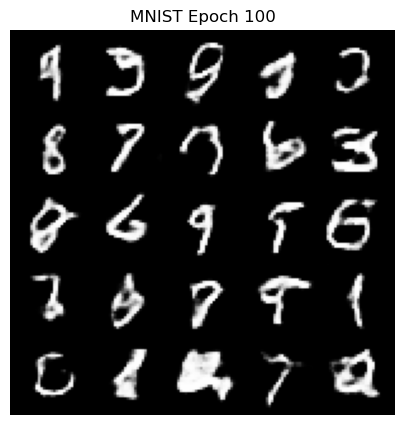

[MNIST] Epoch 110/200  D_loss: 0.9217  D_acc: 0.7656  G_loss: 1.4275


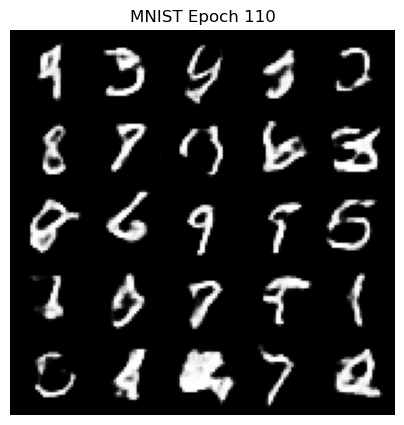

[MNIST] Epoch 120/200  D_loss: 0.8902  D_acc: 0.8125  G_loss: 1.2119


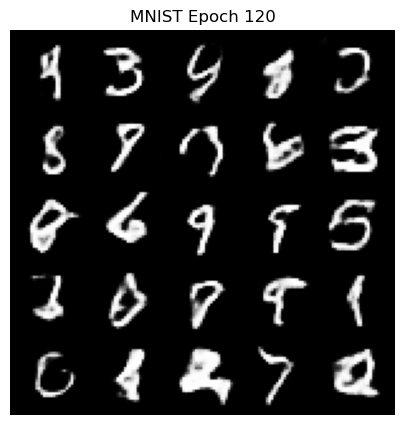

[MNIST] Epoch 130/200  D_loss: 0.9915  D_acc: 0.7188  G_loss: 1.2502


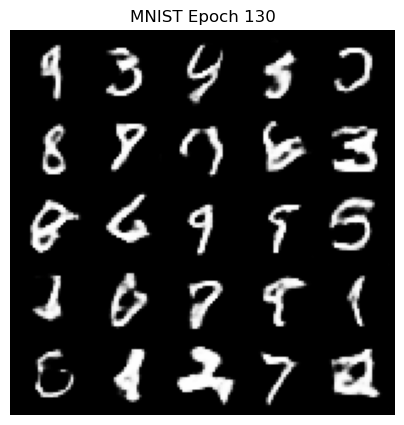

[MNIST] Epoch 140/200  D_loss: 0.9501  D_acc: 0.7344  G_loss: 1.2229


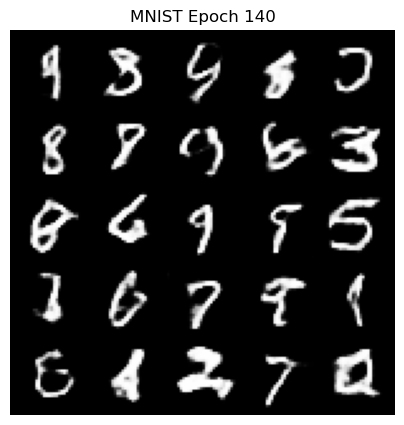

[MNIST] Epoch 150/200  D_loss: 0.9982  D_acc: 0.7500  G_loss: 1.3198


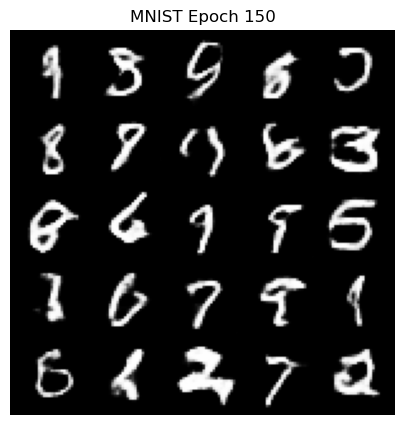

[MNIST] Epoch 160/200  D_loss: 1.1222  D_acc: 0.7188  G_loss: 1.4584


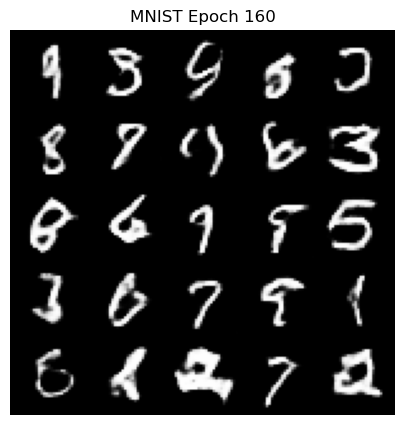

[MNIST] Epoch 170/200  D_loss: 0.9586  D_acc: 0.7969  G_loss: 1.2407


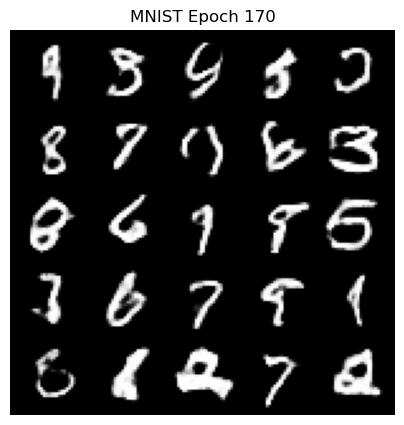

[MNIST] Epoch 180/200  D_loss: 0.9986  D_acc: 0.7656  G_loss: 1.3604


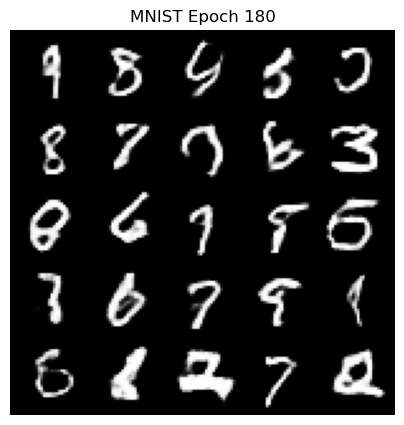

[MNIST] Epoch 190/200  D_loss: 1.2363  D_acc: 0.7031  G_loss: 1.5942


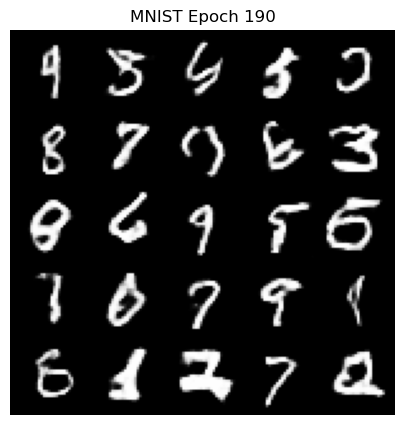

[MNIST] Epoch 200/200  D_loss: 0.8765  D_acc: 0.7969  G_loss: 1.3436


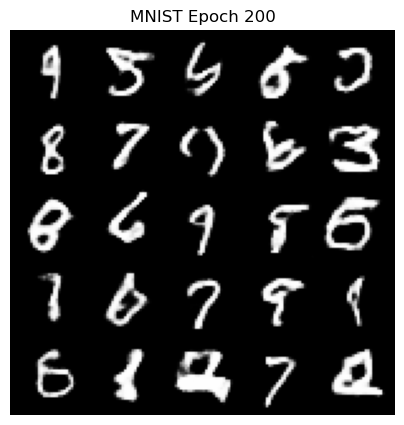

[FashionMNIST] Epoch 1/200  D_loss: 1.0326  D_acc: 0.8125  G_loss: 2.8588


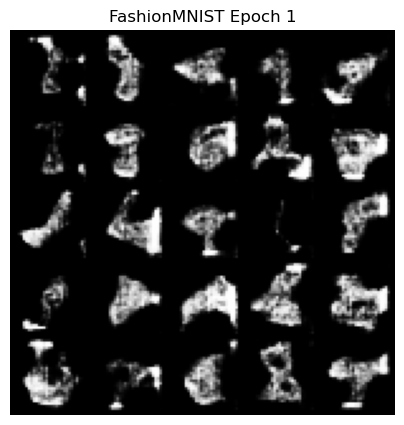

[FashionMNIST] Epoch 10/200  D_loss: 0.7129  D_acc: 0.8438  G_loss: 2.3276


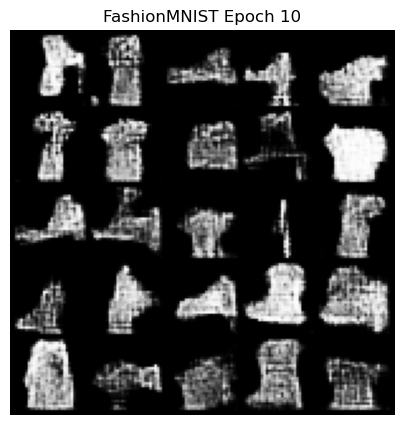

[FashionMNIST] Epoch 20/200  D_loss: 0.5742  D_acc: 0.8438  G_loss: 1.9996


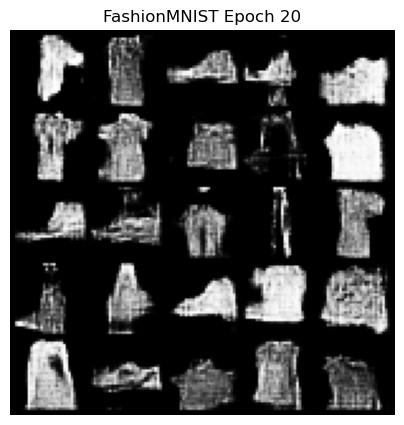

[FashionMNIST] Epoch 30/200  D_loss: 0.8472  D_acc: 0.8281  G_loss: 1.3364


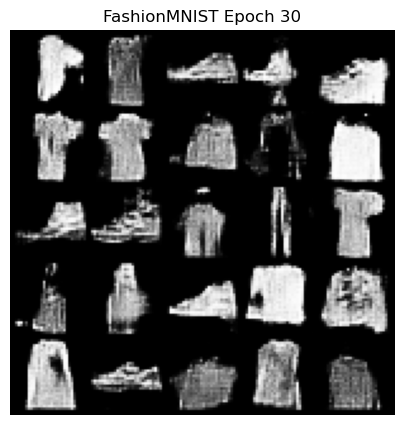

[FashionMNIST] Epoch 40/200  D_loss: 0.8047  D_acc: 0.8438  G_loss: 1.8252


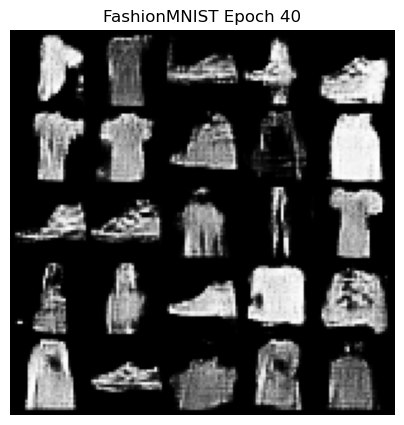

[FashionMNIST] Epoch 50/200  D_loss: 0.8937  D_acc: 0.8125  G_loss: 1.8592


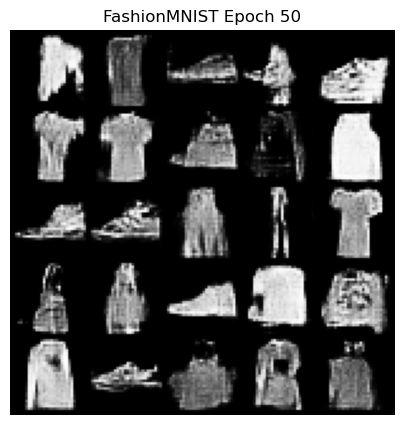

[FashionMNIST] Epoch 60/200  D_loss: 0.8137  D_acc: 0.8125  G_loss: 1.2387


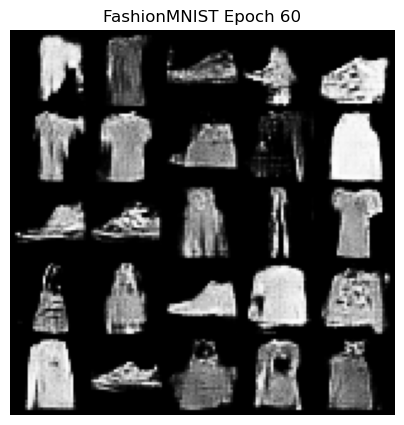

[FashionMNIST] Epoch 70/200  D_loss: 0.8685  D_acc: 0.7656  G_loss: 1.6487


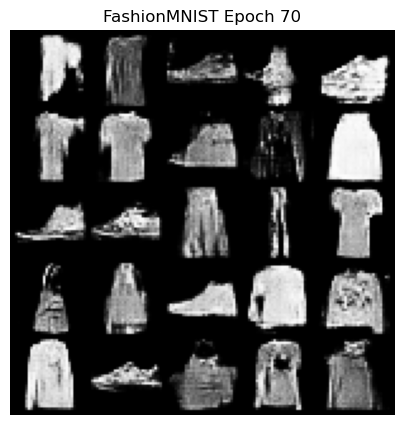

[FashionMNIST] Epoch 80/200  D_loss: 1.0123  D_acc: 0.7656  G_loss: 1.8260


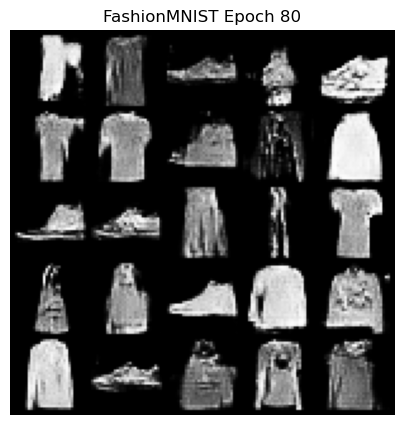

[FashionMNIST] Epoch 90/200  D_loss: 0.9981  D_acc: 0.8125  G_loss: 1.3116


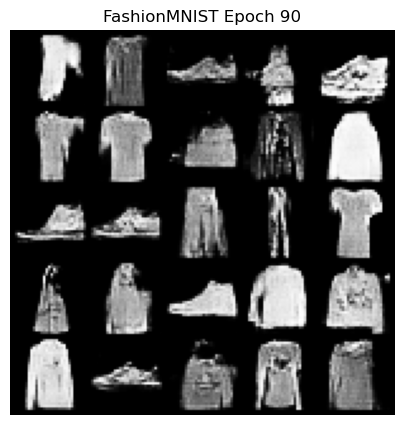

[FashionMNIST] Epoch 100/200  D_loss: 0.9662  D_acc: 0.7500  G_loss: 1.3461


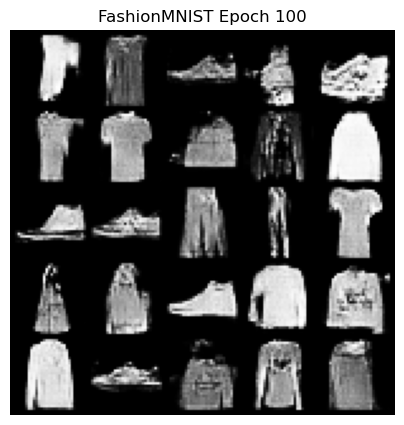

[FashionMNIST] Epoch 110/200  D_loss: 1.0599  D_acc: 0.7500  G_loss: 1.6485


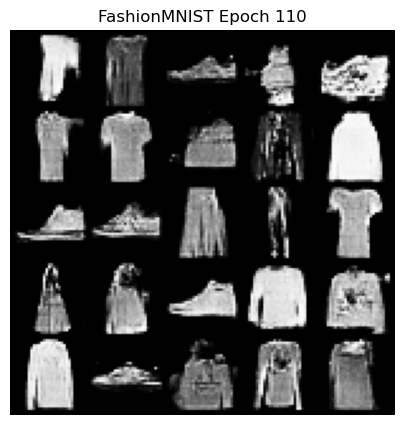

[FashionMNIST] Epoch 120/200  D_loss: 1.1143  D_acc: 0.7188  G_loss: 1.2517


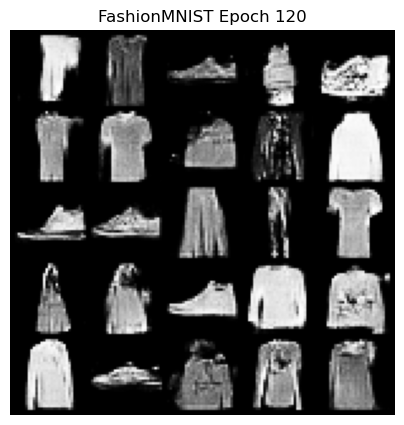

[FashionMNIST] Epoch 130/200  D_loss: 1.0087  D_acc: 0.7344  G_loss: 1.5759


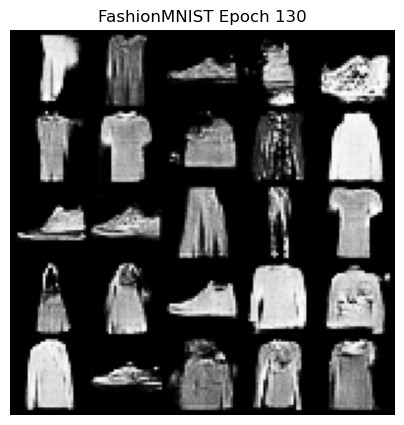

[FashionMNIST] Epoch 140/200  D_loss: 0.7400  D_acc: 0.8594  G_loss: 1.2973


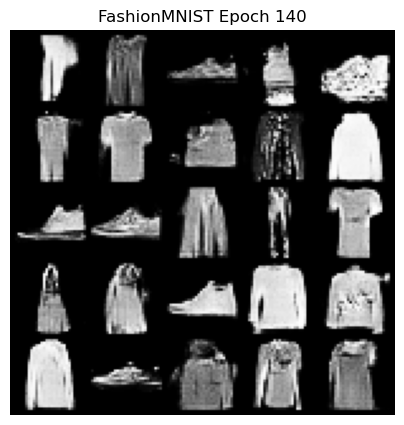

[FashionMNIST] Epoch 150/200  D_loss: 0.8351  D_acc: 0.8438  G_loss: 1.5029


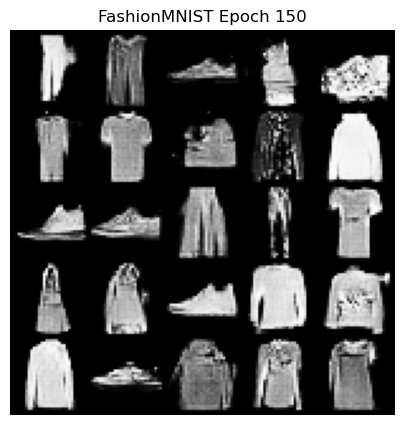

[FashionMNIST] Epoch 160/200  D_loss: 0.9614  D_acc: 0.7344  G_loss: 1.3011


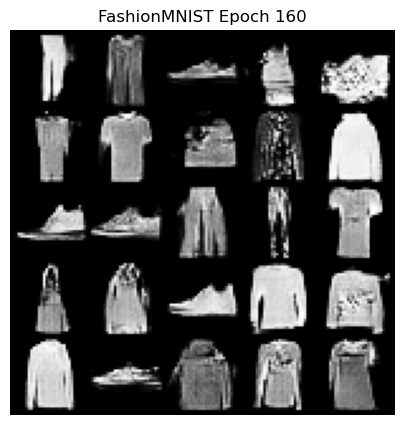

[FashionMNIST] Epoch 170/200  D_loss: 0.9636  D_acc: 0.7500  G_loss: 1.4137


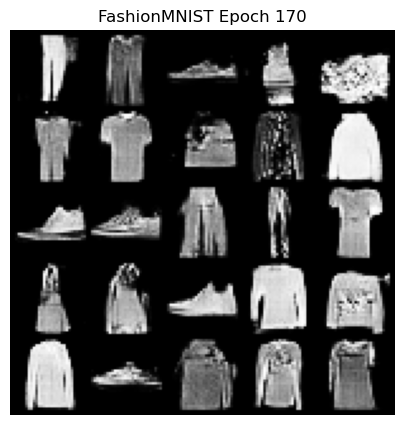

[FashionMNIST] Epoch 180/200  D_loss: 1.0666  D_acc: 0.7344  G_loss: 1.5033


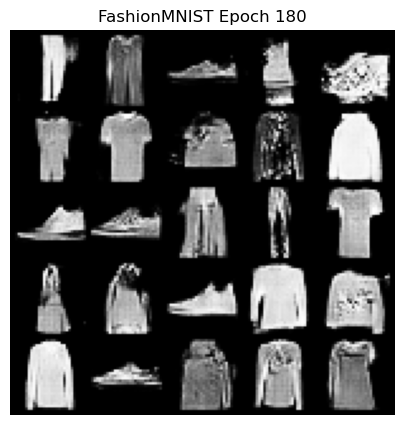

[FashionMNIST] Epoch 190/200  D_loss: 1.0065  D_acc: 0.7344  G_loss: 1.1685


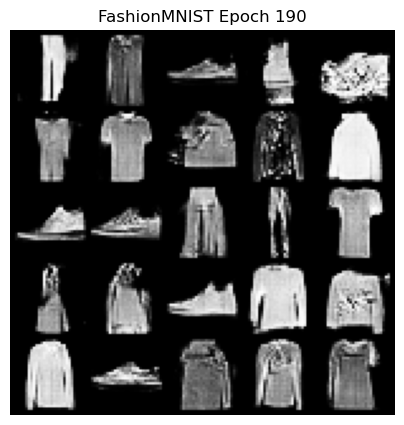

[FashionMNIST] Epoch 200/200  D_loss: 1.0632  D_acc: 0.7500  G_loss: 1.2137


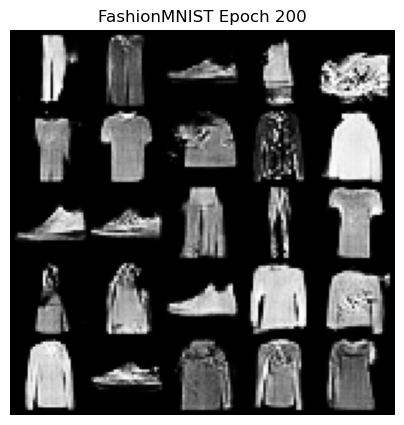

[Combined] Epoch 1/200  D_loss: 0.6577  D_acc: 0.8125  G_loss: 1.6431


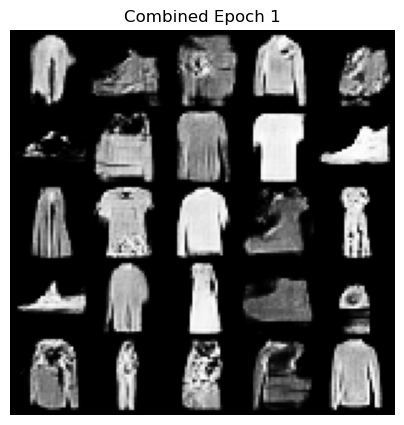

[Combined] Epoch 10/200  D_loss: 0.8106  D_acc: 0.7969  G_loss: 1.6499


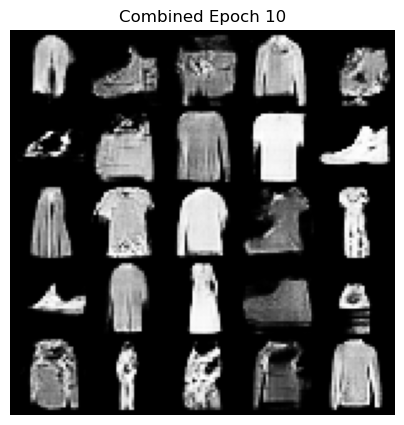

[Combined] Epoch 20/200  D_loss: 0.7851  D_acc: 0.7969  G_loss: 1.7152


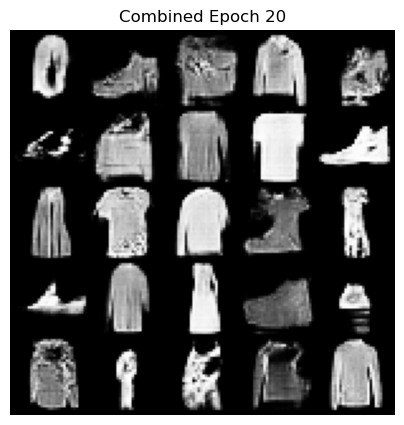

[Combined] Epoch 30/200  D_loss: 0.8350  D_acc: 0.7812  G_loss: 1.4515


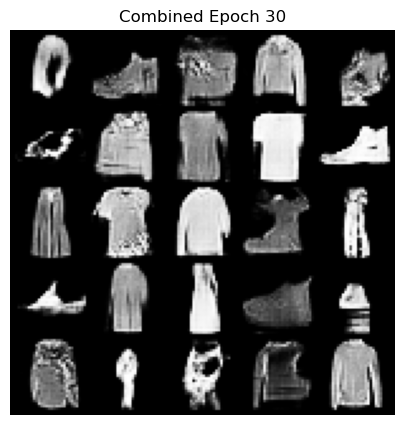

[Combined] Epoch 40/200  D_loss: 1.0135  D_acc: 0.7500  G_loss: 1.8970


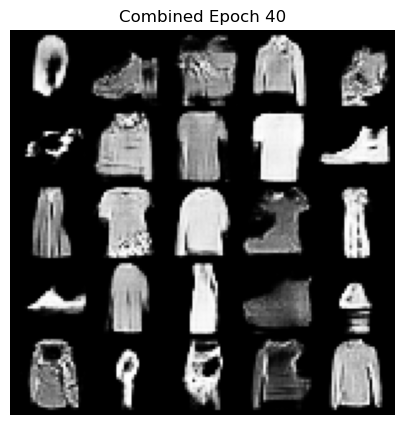

[Combined] Epoch 50/200  D_loss: 0.7233  D_acc: 0.8438  G_loss: 1.4976


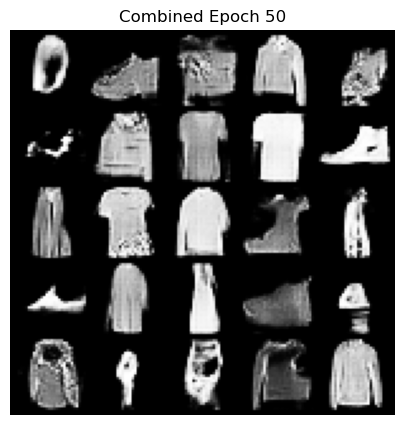

[Combined] Epoch 60/200  D_loss: 1.0248  D_acc: 0.7812  G_loss: 1.8203


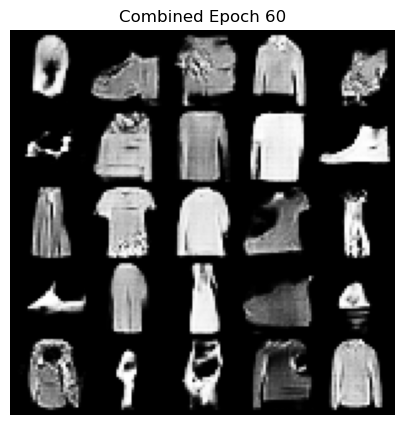

[Combined] Epoch 70/200  D_loss: 0.6219  D_acc: 0.8906  G_loss: 1.5218


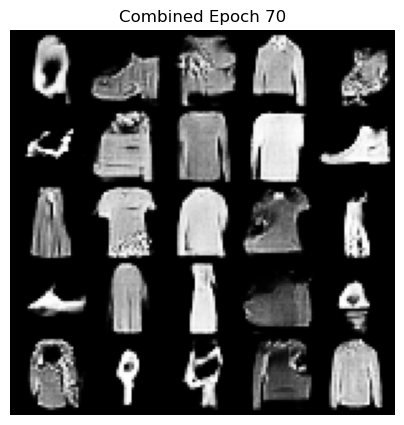

[Combined] Epoch 80/200  D_loss: 0.9957  D_acc: 0.7656  G_loss: 1.8144


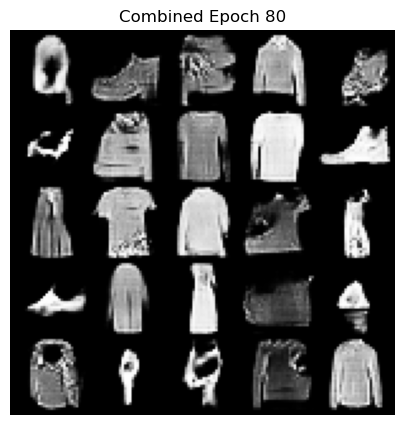

[Combined] Epoch 90/200  D_loss: 0.8936  D_acc: 0.7344  G_loss: 1.4646


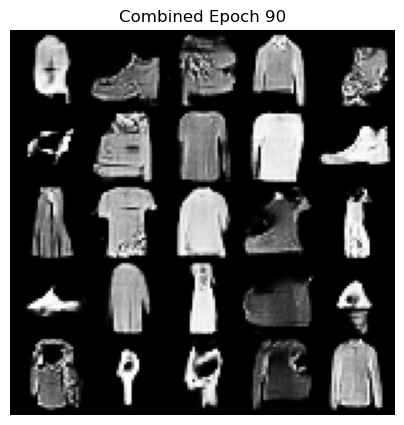

[Combined] Epoch 100/200  D_loss: 0.7801  D_acc: 0.8281  G_loss: 1.6694


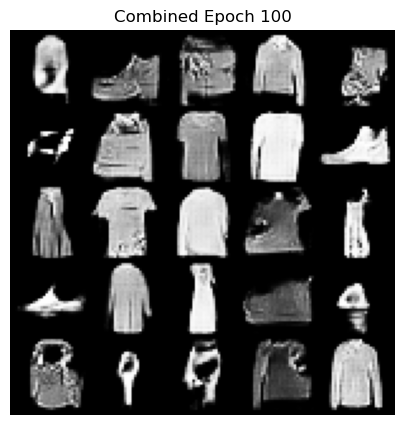

[Combined] Epoch 110/200  D_loss: 0.6034  D_acc: 0.8750  G_loss: 1.2503


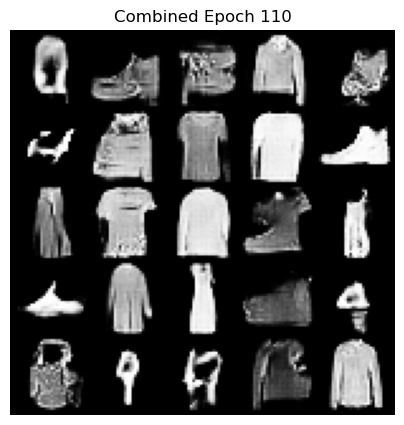

[Combined] Epoch 120/200  D_loss: 1.0475  D_acc: 0.7812  G_loss: 1.7389


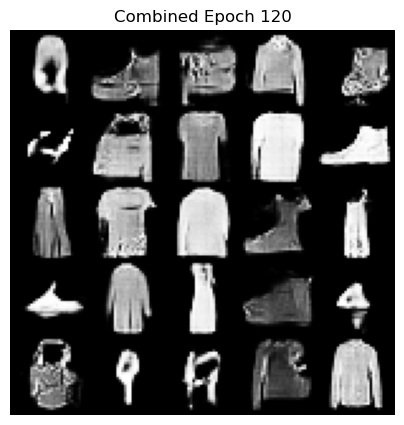

[Combined] Epoch 130/200  D_loss: 1.0907  D_acc: 0.7500  G_loss: 2.0493


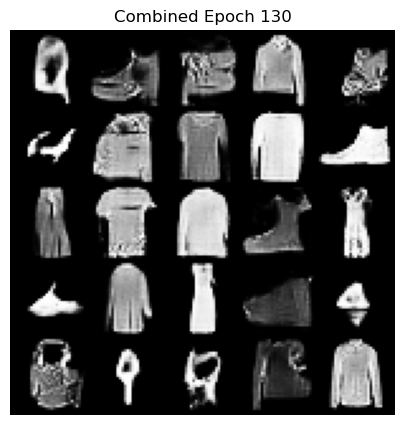

[Combined] Epoch 140/200  D_loss: 0.8268  D_acc: 0.7969  G_loss: 1.4046


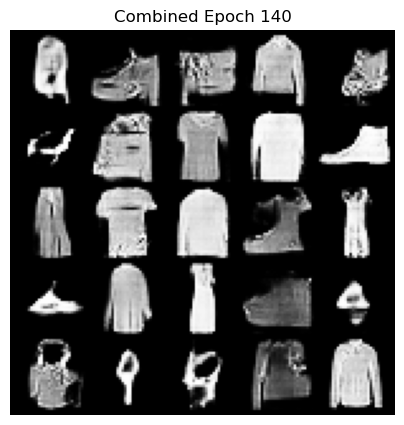

[Combined] Epoch 150/200  D_loss: 1.0475  D_acc: 0.7500  G_loss: 1.7598


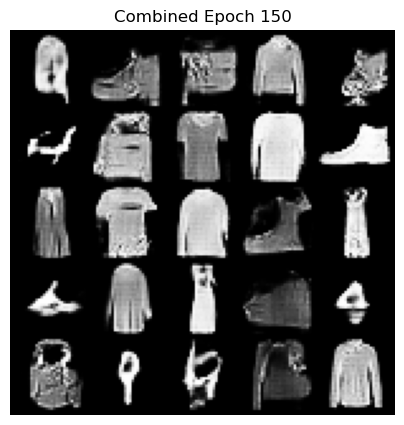

[Combined] Epoch 160/200  D_loss: 0.9204  D_acc: 0.7656  G_loss: 1.3934


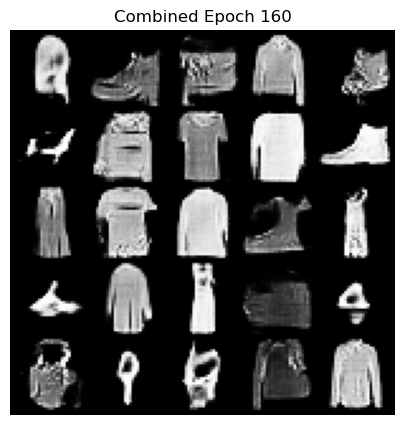

[Combined] Epoch 170/200  D_loss: 1.1321  D_acc: 0.7656  G_loss: 1.5575


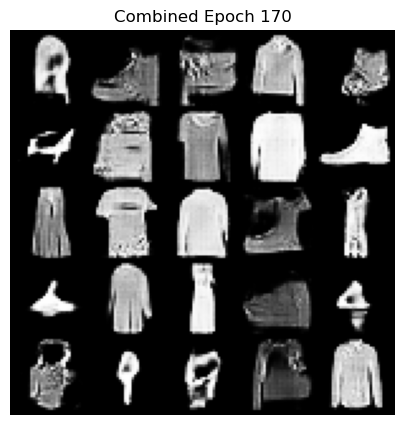

[Combined] Epoch 180/200  D_loss: 0.9094  D_acc: 0.7500  G_loss: 1.9024


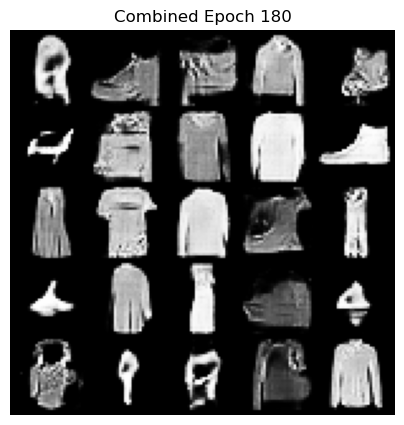

[Combined] Epoch 190/200  D_loss: 0.9373  D_acc: 0.7344  G_loss: 1.6302


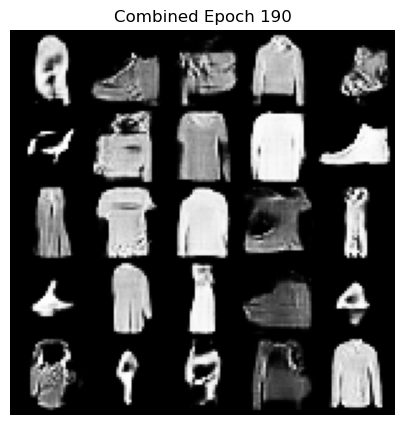

[Combined] Epoch 200/200  D_loss: 0.8164  D_acc: 0.7656  G_loss: 1.4189


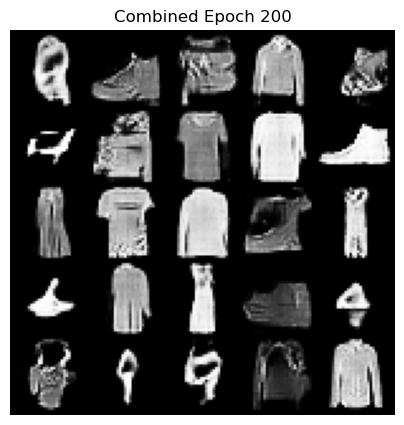

In [ ]:
# Train GANs on each dataset
train_gan(loader_mnist,    name='MNIST')
train_gan(loader_fmnist,   name='FashionMNIST')
train_gan(loader_combined, name='Combined')